In [ ]:
import requests
import pandas as pd
import json
import seaborn as sns
from matplotlib import pyplot as plt
from textwrap import wrap

## Introdução ao EDA (Exploratory Data Analysis)

Sempre que deparamos com um desafio envolvendo dados, temos o dever de entender melhor esses dados que estamos transformando.

Uma das formas mais utilizadas para entender os nossos dados é o **Processo de EDA (Exploratory Data Analysis ou Análise Exploratória de Dados)**

Muitas vezes não sabemos como fazer a extração de informações e também quais objetivos sobre essa base. Uma situação exemplo é quando um cientista de dados que trabalhou anos em uma empresa do ramo de Telecomunicações, após uma recolocação de mercado está atualmente alocado em uma empresa da área de Educação. Cientistas de dados devem estar preparados para transformar dados de qualquer natureza.

O EDA consiste em um processo genérico para obtenção de informações e Conclusões em bases de dados, como meio nesse processo utilizamos ferramentas de Estatística, Representações Gráficas e Modelos Matemáticos para extração dessas informações. O processo pode ser dividido em 6 Etapas:

1. **Coleta e Dominância do Conhecimento**: Obter os dados requeridos e dominar conhecimentos relacionados ao conhecimento dos dados

2. **Análise Descritiva**: Entender a estrutura e natureza dos dados, obtendo uma visão completa das características da base de dados.

3. **Consolidação dos Dados**: Modificar a estrutura e natureza dos dados conforme os objetivos estabelecidos.

3. **Análise sob a Teoria Distribuição Normal**: Entender o comportamento dos dados conforme a teoria da Distribuição Normal.

4. **Tratamento de Valores Nulos e Valores Atípicos**: A ausência de dados e valores fora da realidade conforme a Teoria Distribuição Normal  contaminam as informações geradas a partir da base analisada, portanto, esses valores devem ser mitigados ou removidos.

5. **Visualização de Dados**: A representação gráfica dos dados analisados é uma maneira eficiente de gerar informações.

6. **Extração de Padrões**: Usando algoritmos podemos verificar padrões escondidos que gráficos ou Estatística básica não alcançam, modelos de machine learning podem ser utilizados para entendimento da base analisada.

**Não há um consenso sobre um definitivo do processo de EDA, o informado neste documento é um amálgama de várias bibliografias.**


Você sabe quanto e com o que o senadores gastaram com as verbas de Cotas para Exercício da Atividade Parlamentar dos Senadores (CEAPS)?

CEAPS são gastos pertinentes à atividade parlamentar do senador ao longo do seu mandato, esses gastos são ressarcidos pela união.

será que nossos representantes no senado fazem o uso consciente desses recursos?

Vamos explorar a base desses gastos e prover resultados quali-quantitativos para determinar se há uma boa gestão.

Dados Abertos referentes ao Senado Federal estão presentes no site https://www12.senado.leg.br/transparencia

## Coleta e Dominância do Conhecimento

In [ ]:
response = requests.get('https://adm.senado.gov.br/adm-dadosabertos/api/v1/senadores/despesas_ceaps/2018/').content

In [ ]:
data = json.loads(response)

data;

In [ ]:
df = pd.json_normalize(data)

In [ ]:
df

,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
0,2097818,7,2018,5,AÉCIO NEVES,Aquisição de material de consumo para uso no e...,00896242000105,FIBRA Telecomunicações LTDA,2018/366,2018-05-15,Locação de equipamento telefônico.,171.03
1,2098479,7,2018,5,AÉCIO NEVES,"Contratação de consultorias, assessorias, pesq...",26894399000195,JOÃO FRANCISCO MEIRELLES SILVA,2018/11,2018-06-11,Contratação de serviços de apoio ao parlamenta...,7000.00
2,2096732,7,2018,5,AÉCIO NEVES,"Locomoção, hospedagem, alimentação, combustíve...",05217384000627,H PLUS ADMINISTRAÇÃO E HOTELARIA LTDA - SCP AT...,97567,2018-05-09,Hospedagem - Brasília/DF da Assessora Maria He...,424.35
3,2096740,3,2018,5,AÉCIO NEVES,"Locomoção, hospedagem, alimentação, combustíve...",00031708000100,SINPETAXI,s/n,2018-05-09,Maria Heloísa Cardoso - matr. 239190 - Assesso...,60.00
4,2098377,6,2018,5,AÉCIO NEVES,"Passagens aéreas, aquáticas e terrestres nacio...",16978175000108,ADRIA VIAGENS E TURISMO LTDA ME,SESNQI,2018-04-25,"Companhia Aérea: GOL, Localizador: SESNQI. Pas...",1064.52
...,...,...,...,...,...,...,...,...,...,...,...,...
24487,2108809,3,2018,10,ZEZÉ PERRELLA,"Aluguel de imóveis para escritório político, c...",09722379000118,Masb 21 Empreendimento Imobiliário Ltda,s/n,2018-10-15,None,13.60
24488,2108808,3,2018,10,ZEZÉ PERRELLA,"Aluguel de imóveis para escritório político, c...",09722379000118,Masb 21 Empreendimento Imobiliário Ltda,S/N,2018-10-15,None,225.28
24489,2108805,3,2018,10,ZEZÉ PERRELLA,"Aluguel de imóveis para escritório político, c...",20493131000165,Prosind,S/N,2018-10-05,None,356.40
24490,2109320,4,2018,10,ZEZÉ PERRELLA,"Aluguel de imóveis para escritório político, c...",02558157000162,Vivo,s/n,2018-11-01,None,75.99


In [ ]:
# Realizar consumo dos dados via api de forma automatizada de 2015 à 2022.

datas = [2015,2016,2017,2018,2019,2020,2021,2022]

for x in datas:
    response = requests.get('https://adm.senado.gov.br/adm-dadosabertos/api/v1/senadores/despesas_ceaps/{}/'.format(x)).content

    if x == min(datas):
        data = json.loads(response)
    else:
        data.extend(json.loads(response))

df = pd.json_normalize(data)

In [ ]:
df

,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
0,2005031,1,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05914650000166,ENERGISA,000049838,2015-03-05,Pagamento energia elétrica para o escritório p...,56.51
1,2005035,1,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05914650000166,ENERGISA,000049835,2015-03-05,Pagamento energia elétrica para o escritório p...,236.03
2,2002762,3,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",00494802863,GILBERTO PISELO DO NASCIMENTO,003/15,2015-03-03,Despesa com pagamento de aluguel de imóvel uti...,6000.00
3,2005034,4,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05423963000111,OI MÓVEL S.A.,567158392,2015-03-06,Pagamento de telefonia para uso do escritório ...,413.13
4,2005037,1,2015,3,ACIR GURGACZ,Divulgação da atividade parlamentar,84721745000130,O.F. CALADO EDIÇÕES,000280,2015-03-20,Despesa com divulgação da atividade parlamenta...,2000.00
...,...,...,...,...,...,...,...,...,...,...,...,...
173666,2191292,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",84146638000125,POSTO CAVALO DE AÇO LTDA.,133117,2022-10-28,None,315.04
173667,2191295,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",02280133002219,POSTO ICCAR LTDA.,146850,2022-10-20,None,450.02
173668,2188422,6,2022,10,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",09296295000160,AZUL,BI7EWW,2022-10-12,"Companhia Aérea: AZUL, Localizador: BI7EWW. Pa...",918.93
173669,2187707,6,2022,10,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22052777000132,Exceller Tour,DNLRGP,2022-10-03,"Companhia Aérea: GOL, Localizador: DNLRGP. Pas...",3275.31


In [ ]:
df.to_csv('ceaps_senado_2015_2022.csv')

In [ ]:
response = requests.get('https://legis.senado.leg.br/dadosabertos/senador/lista/legislatura/54/56.json').content

data = json.loads(response)

data['ListaParlamentarLegislatura']['Parlamentares']['Parlamentar'];

In [ ]:
data = data['ListaParlamentarLegislatura']['Parlamentares']['Parlamentar']

In [ ]:
df_senadores = pd.json_normalize(data)

In [ ]:
df_senadores

,IdentificacaoParlamentar.CodigoParlamentar,IdentificacaoParlamentar.NomeParlamentar,IdentificacaoParlamentar.NomeCompletoParlamentar,IdentificacaoParlamentar.SexoParlamentar,IdentificacaoParlamentar.FormaTratamento,IdentificacaoParlamentar.SiglaPartidoParlamentar,Mandatos.Mandato.CodigoMandato,Mandatos.Mandato.UfParlamentar,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio,...,Mandatos.Mandato,Mandatos.Mandato.Exercicios.Exercicio.CodigoExercicio,Mandatos.Mandato.Exercicios.Exercicio.DataInicio,Mandatos.Mandato.Exercicios.Exercicio.DataFim,Mandatos.Mandato.Exercicios.Exercicio.SiglaCausaAfastamento,Mandatos.Mandato.Exercicios.Exercicio.DescricaoCausaAfastamento,Mandatos.Mandato.Exercicios.Exercicio.DataLeitura,IdentificacaoParlamentar.UfParlamentar,Mandatos.Mandato.Suplentes.Suplente,Mandatos.Mandato.Exercicios.Exercicio
0,5573,Abel Rebouças,Abel Rebouças São José,Masculino,Senador,PDT,492,BA,55,2015-02-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5154,Abiancy Cadoso Rosa,Abiancy Cadoso Rosa,Masculino,Senador,CIDADANIA,487,PA,54,2011-02-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4981,Acir Gurgacz,Acir Marcos Gurgacz,Masculino,Senador,PDT,NaN,NaN,NaN,NaN,...,"[{'CodigoMandato': '434', 'UfParlamentar': 'RO...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4815,Ada Mello,Ada Mercedes de Mello Marques Luz,Feminino,Senadora,PTB,345,AL,53,2007-02-01,...,NaN,2505,2008-09-15,2009-01-10,RET,Retorno do titular,2008-09-15,NaN,NaN,NaN
4,5918,Adilson Gomes,Adilson Gomes Silva,Masculino,Senador,NaN,526,PE,56,2019-02-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,3806,Zequinha Marinho,José da Cruz Marinho,Masculino,Senador,PODEMOS,566,PA,56,2019-02-01,...,NaN,2916,2019-02-01,NaN,NaN,NaN,NaN,PA,"[{'DescricaoParticipacao': '1º Suplente', 'Cod...",NaN
475,5144,Zeze Perrella,José Perrella de Oliveira Costa,Masculino,Senador,MDB,441,MG,54,2011-02-01,...,NaN,2643,2011-07-11,2019-01-31,TER,Término do mandato,NaN,NaN,NaN,NaN
476,5118,Zonir Freitas Tetila,Zonir Freitas Tetila,Masculino,Senador,PT,447,MS,54,2011-02-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
477,5184,Zé Santana,José Ribamar Noleto de Santana,Masculino,Senador,MDB,488,PI,54,2011-02-01,...,NaN,2878,2018-12-13,2019-01-31,TER,Término do mandato,NaN,NaN,NaN,NaN


In [ ]:
df_senadores.to_csv('senadores_2015_2022.csv')

In [ ]:
df_senadores = pd.read_csv('senadores_2015_2022.csv')

In [ ]:
df = pd.read_csv('ceaps_senado_2015_2022.csv')

## Analise Descritiva

#### DF

In [ ]:
df.ano.min()

2015

In [ ]:
df.ano.max()

2022

In [ ]:
df.columns

Index(['Unnamed: 0', 'id', 'tipoDocumento', 'ano', 'mes', 'nomeSenador',
       'tipoDespesa', 'cpfCnpj', 'fornecedor', 'documento', 'data',
       'detalhamento', 'valorReembolsado'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173671 entries, 0 to 173670
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        173671 non-null  int64  
 1   id                173671 non-null  int64  
 2   tipoDocumento     173671 non-null  int64  
 3   ano               173671 non-null  int64  
 4   mes               173671 non-null  int64  
 5   nomeSenador       173671 non-null  object 
 6   tipoDespesa       173671 non-null  object 
 7   cpfCnpj           173671 non-null  int64  
 8   fornecedor        173671 non-null  object 
 9   documento         162078 non-null  object 
 10  data              173671 non-null  object 
 11  detalhamento      121691 non-null  object 
 12  valorReembolsado  173671 non-null  float64
dtypes: float64(1), int64(6), object(6)
memory usage: 17.2+ MB


In [ ]:
df[['valorReembolsado']].describe()

,valorReembolsado
count,173671.000000
mean,1153.989141
std,2887.331084
min,-1500.000000
25%,135.000000
50%,356.500000
75%,1200.000000
max,270000.000000


In [ ]:
# Qual é o registro com Valor Minímo da Coluna valorReembolsado?
df[df['valorReembolsado'] == df['valorReembolsado'].min()]

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
7939,7939,2001228,3,2015,2,GLADSON CAMELI,"Aluguel de imóveis para escritório político, c...",63600449000100,Arras Adm. de Bens Imóveis Limpeza e Conservaç...,NaN,2015-01-15,Contrato de locação de Imóvel comercial do esc...,-1500.0


In [ ]:
# Qual é o registro com Valor Máximo da Coluna valorReembolsado?
df[df['valorReembolsado'] == df['valorReembolsado'].max()]

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
57805,57805,2090997,1,2017,12,DAVI ALCOLUMBRE,Divulgação da atividade parlamentar,29337655000131,Start print Comunicação Visual Eireli,36,2018-03-15,NaN,270000.0


#### DF_SENADORES

In [ ]:
df_senadores.columns

Index(['Unnamed: 0', 'IdentificacaoParlamentar.CodigoParlamentar',
       'IdentificacaoParlamentar.NomeParlamentar',
       'IdentificacaoParlamentar.NomeCompletoParlamentar',
       'IdentificacaoParlamentar.SexoParlamentar',
       'IdentificacaoParlamentar.FormaTratamento',
       'IdentificacaoParlamentar.SiglaPartidoParlamentar',
       'Mandatos.Mandato.CodigoMandato', 'Mandatos.Mandato.UfParlamentar',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataFim',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.NumeroLegislatura',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.DataInicio',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.DataFim',
       'Mandatos.Mandato.DescricaoParticipacao',
       'Mandatos.Mandato.Titular.DescricaoParticipacao',
       'Mandatos.Mandato.Titular.CodigoParlamentar',
       'Mandatos.Mand

In [ ]:
df_senadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 37 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Unnamed: 0                                                       479 non-null    int64  
 1   IdentificacaoParlamentar.CodigoParlamentar                       479 non-null    int64  
 2   IdentificacaoParlamentar.NomeParlamentar                         479 non-null    object 
 3   IdentificacaoParlamentar.NomeCompletoParlamentar                 479 non-null    object 
 4   IdentificacaoParlamentar.SexoParlamentar                         479 non-null    object 
 5   IdentificacaoParlamentar.FormaTratamento                         479 non-null    object 
 6   IdentificacaoParlamentar.SiglaPartidoParlamentar                 366 non-null    object 
 7   Mandatos.Mandato.CodigoMandato              

In [ ]:
df_senadores.head(10)

,Unnamed: 0,IdentificacaoParlamentar.CodigoParlamentar,IdentificacaoParlamentar.NomeParlamentar,IdentificacaoParlamentar.NomeCompletoParlamentar,IdentificacaoParlamentar.SexoParlamentar,IdentificacaoParlamentar.FormaTratamento,IdentificacaoParlamentar.SiglaPartidoParlamentar,Mandatos.Mandato.CodigoMandato,Mandatos.Mandato.UfParlamentar,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura,...,Mandatos.Mandato,Mandatos.Mandato.Exercicios.Exercicio.CodigoExercicio,Mandatos.Mandato.Exercicios.Exercicio.DataInicio,Mandatos.Mandato.Exercicios.Exercicio.DataFim,Mandatos.Mandato.Exercicios.Exercicio.SiglaCausaAfastamento,Mandatos.Mandato.Exercicios.Exercicio.DescricaoCausaAfastamento,Mandatos.Mandato.Exercicios.Exercicio.DataLeitura,IdentificacaoParlamentar.UfParlamentar,Mandatos.Mandato.Suplentes.Suplente,Mandatos.Mandato.Exercicios.Exercicio
0,0,5573,Abel Rebouças,Abel Rebouças São José,Masculino,Senador,PDT,492.0,BA,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,5154,Abiancy Cadoso Rosa,Abiancy Cadoso Rosa,Masculino,Senador,CIDADANIA,487.0,PA,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,4981,Acir Gurgacz,Acir Marcos Gurgacz,Masculino,Senador,PDT,NaN,NaN,NaN,...,"[{'CodigoMandato': '434', 'UfParlamentar': 'RO...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,4815,Ada Mello,Ada Mercedes de Mello Marques Luz,Feminino,Senadora,PTB,345.0,AL,53.0,...,NaN,2505.0,2008-09-15,2009-01-10,RET,Retorno do titular,2008-09-15,NaN,NaN,NaN
4,4,5918,Adilson Gomes,Adilson Gomes Silva,Masculino,Senador,NaN,526.0,PE,56.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,5625,Adilson Silva dos Santos,Adilson Silva dos Santos,Masculino,Senador,PEN,497.0,RS,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,6026,Afonso Parente,Afonso Valter Parente Pinto,Masculino,Senador,NaN,578.0,RR,56.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,4881,Afonso Sérgio Fernandes Ribeiro,Afonso Sérgio Fernandes Ribeiro,Masculino,Senador,NaN,348.0,MA,53.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,5170,Agimiro Dias da Costa,Agimiro Dias da Costa,Masculino,Senador,PSDB,451.0,TO,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,5140,Airton Sandoval,Airton Sandoval Santana,Masculino,Senador,MDB,485.0,SP,54.0,...,NaN,2827.0,2017-03-09,2018-12-31,RET,Retorno do titular,NaN,NaN,NaN,NaN


Considerações da Analise Descritiva para próxima etapa de Consolidação dos Dados:

Ações Realizadas:
1. Carga dos Dados via API.
2. União documentos.

Ações Futuras:
1. Coluna Date está em string, transformar para datetime.
2. Existe Números Negativos Na Coluna valorReembolsado, verificar tratativa.
3. Apagar Colunas desnecessárias
4. Ajustar Nome Parlamentar
5. Merge das Tabelas df e df_senadores

## Consolidação dos Dados

#### DF

In [ ]:
# Testar se a col data pode ser transformada em datetime
df['data'].astype('datetime64')

OutOfBoundsDatetime: ignored

Vemos que não possivel transformar toda a coluna data em datetime, o erro acusado que existes valores na coluna fora calendário do Pandas.

In [ ]:
# filtro se exite mesmo um registo com esses valores
df[df['data'] == '2915-10-06']

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
10485,10485,2029364,6,2015,10,JOÃO ALBERTO SOUZA,"Passagens aéreas, aquáticas e terrestres nacio...",16978175000108,ADRIA VIAGENS E TURISMO LTDA,NaN,2915-10-06,"Companhia Aérea: GOL, Localizador: HF2VJM. Pas...",993.46


In [ ]:
# Podemos transformar os dados em data mitigando os erros com o coerce
# Criamos a coluna data_ para testes
df['data_'] = pd.to_datetime(df['data'], errors = 'coerce')

In [ ]:
# Filtro com valores de data com problemas
df[df['data_'].isna()]

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado,data_
10485,10485,2029364,6,2015,10,JOÃO ALBERTO SOUZA,"Passagens aéreas, aquáticas e terrestres nacio...",16978175000108,ADRIA VIAGENS E TURISMO LTDA,NaN,2915-10-06,"Companhia Aérea: GOL, Localizador: HF2VJM. Pas...",993.46,NaT
11890,11890,2016913,7,2015,8,JOSÉ AGRIPINO,Serviços de Segurança Privada,10209529000173,Branco Oliveira Limpeza e Conservação Ltda.,034,0201-08-25,NaN,4029.11,NaT
12378,12378,2011103,6,2015,4,JOSÉ MEDEIROS,"Passagens aéreas, aquáticas e terrestres nacio...",16978175000108,ADRIA VIAGENS,NaN,5015-02-24,"Companhia Aérea: AVIANCA, Localizador: 42BZ8L....",821.25,NaT
18516,18516,2008125,6,2015,4,PAULO ROCHA,"Passagens aéreas, aquáticas e terrestres nacio...",2012862000160,TAM Linhas Aéreas S.A,XGUHHW,0215-04-21,"Companhia Aérea: TAM, Localizador: XGUHHW. Pas...",853.93,NaT
18536,18536,2008124,6,2015,4,PAULO ROCHA,"Passagens aéreas, aquáticas e terrestres nacio...",7575651000159,VRG Linhas Aereas S.A.,THIEUG,0215-04-22,"Companhia Aérea: GOL, Localizador: THIEUG. Pas...",813.93,NaT
22742,22742,2007486,6,2015,5,TELMÁRIO MOTA,"Passagens aéreas, aquáticas e terrestres nacio...",12795601000117,GLOBAL VIAGENS EVENTOS E TURISMO,010/15,5201-05-08,"Companhia Aérea: TAM, Localizador: 5MHYZ3. Pas...",2659.35,NaT
28214,28214,2050224,4,2016,10,ARMANDO MONTEIRO,"Aluguel de imóveis para escritório político, c...",41054867000107,Jadan Office Center,1101610021,5017-07-20,"Taxa de condomínio do escritório parlamentar, ...",811.89,NaT
38590,38590,2034257,7,2016,4,JOSÉ MEDEIROS,"Locomoção, hospedagem, alimentação, combustíve...",12262251000123,HOTEL GRAN ODARA LTDA,65509,3016-04-02,despesa com hospedagem,259.90,NaT
39728,39728,2051549,7,2016,10,KÁTIA ABREU,"Locomoção, hospedagem, alimentação, combustíve...",56548779000139,Transamérica Comercial e Serviços Ltda SCP La ...,00038600,0200-10-30,"Hospedagem (R$ 648,44) e alimentação (R$ 40,00...",688.44,NaT
39886,39886,2036344,2,2016,4,JOSÉ SERRA,"Locomoção, hospedagem, alimentação, combustíve...",52791571000195,A Ferreira Automóveis LTDA,541327,0216-04-03,Senador José Serra - Aquisição de combustível ...,158.58,NaT


In [ ]:
# Ajuste as datas com problemas no filtro acima

for index, row in df[df['data_'].isna()].iterrows():
    dia = row['data'][-2:]
    df['data'].iloc[index]  = '{}-{}-{}'.format(row['ano'],row['mes'],dia)

<ipython-input-31-2317902dd146>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['data'].iloc[index]  = '{}-{}-{}'.format(row['ano'],row['mes'],dia)


In [ ]:
# Teste a tratativa acima transforma a coluna date em datetime
df['data'].astype('datetime64')

0        2015-03-05
1        2015-03-05
2        2015-03-03
3        2015-03-06
4        2015-03-20
            ...    
173666   2022-10-28
173667   2022-10-20
173668   2022-10-12
173669   2022-10-03
173670   2022-10-04
Name: data, Length: 173671, dtype: datetime64[ns]

In [ ]:
# Transformar os dados para datetime
df['data'] = df['data'].astype('datetime64')
# Apagar a coluna de teste
del df['data_']

In [ ]:
# Verificar se existe valores negativos na col valorReembolsado
# df[df['valorReembolsado'] <= 0]
df[df['valorReembolsado'] < 0]

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
7939,7939,2001228,3,2015,2,GLADSON CAMELI,"Aluguel de imóveis para escritório político, c...",63600449000100,Arras Adm. de Bens Imóveis Limpeza e Conservaç...,NaN,2015-01-15,Contrato de locação de Imóvel comercial do esc...,-1500.0
57390,57390,2068568,7,2017,5,DÁRIO BERGER,"Contratação de consultorias, assessorias, pesq...",73228876000163,TV CLIPAGEM LTDA. EPP.,001661,2017-06-02,Despesa com Monitoramento de Informação Jornal...,-243.4


In [ ]:
# Transforme os valores menores de 0 em Absoluto
df['valorReembolsado'] = abs(df['valorReembolsado'])

#### DF_SENADORES

In [ ]:
# Vamos apagar colunas desnecessárias
del df_senadores['IdentificacaoParlamentar.UrlPaginaParlamentar']
del df_senadores['IdentificacaoParlamentar.EmailParlamentar']
del df_senadores['IdentificacaoParlamentar.UrlPaginaParticular']
del df_senadores['IdentificacaoParlamentar.UrlFotoParlamentar']
del df_senadores['IdentificacaoParlamentar.CodigoPublicoNaLegAtual']
del df_senadores['IdentificacaoParlamentar.FormaTratamento']
del df_senadores['Mandatos.Mandato.Exercicios.Exercicio.SiglaCausaAfastamento']
del df_senadores['IdentificacaoParlamentar.UfParlamentar']
del df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataLeitura']
del df_senadores['Mandatos.Mandato']
del df_senadores['Mandatos.Mandato.Suplentes.Suplente']
del df_senadores['Mandatos.Mandato.Exercicios.Exercicio']

In [ ]:
# Transforme o nome parlamentar em maiuscula
df_senadores['IdentificacaoParlamentar.NomeParlamentar'] = df_senadores['IdentificacaoParlamentar.NomeParlamentar'].apply(lambda x: x.upper())

In [ ]:
# Corrija a Tipagem das colunas de natureza data em objeto para datetime
df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataInicio'] = pd.to_datetime(df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataInicio'], errors = 'coerce')
df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataFim'] = pd.to_datetime(df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataFim'], errors = 'coerce')

df_senadores['Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio'] = pd.to_datetime(df_senadores['Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio'], errors = 'coerce')
df_senadores['Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataFim'] = pd.to_datetime(df_senadores['Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataFim'], errors = 'coerce')

df_senadores['Mandatos.Mandato.SegundaLegislaturaDoMandato.DataInicio'] = pd.to_datetime(df_senadores['Mandatos.Mandato.SegundaLegislaturaDoMandato.DataInicio'], errors = 'coerce')
df_senadores['Mandatos.Mandato.SegundaLegislaturaDoMandato.DataFim'] = pd.to_datetime(df_senadores['Mandatos.Mandato.SegundaLegislaturaDoMandato.DataFim'], errors = 'coerce')

In [ ]:
# Coluna de id para int
df_senadores['IdentificacaoParlamentar.CodigoParlamentar'] = df_senadores['IdentificacaoParlamentar.CodigoParlamentar'].astype(int)

#### Merge dos datasets DF e DF_SENADORES

Para fazer uma união entre bases de dados temos que procurar chaves primárias em comum entre as duas bases em questão.

Qual seria essas chaves?

In [ ]:
df_senadores.head(5)

,Unnamed: 0,IdentificacaoParlamentar.CodigoParlamentar,IdentificacaoParlamentar.NomeParlamentar,IdentificacaoParlamentar.NomeCompletoParlamentar,IdentificacaoParlamentar.SexoParlamentar,IdentificacaoParlamentar.SiglaPartidoParlamentar,Mandatos.Mandato.CodigoMandato,Mandatos.Mandato.UfParlamentar,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio,...,Mandatos.Mandato.Titular.DescricaoParticipacao,Mandatos.Mandato.Titular.CodigoParlamentar,Mandatos.Mandato.Titular.NomeParlamentar,Mandatos.Mandato.Suplentes.Suplente.DescricaoParticipacao,Mandatos.Mandato.Suplentes.Suplente.CodigoParlamentar,Mandatos.Mandato.Suplentes.Suplente.NomeParlamentar,Mandatos.Mandato.Exercicios.Exercicio.CodigoExercicio,Mandatos.Mandato.Exercicios.Exercicio.DataInicio,Mandatos.Mandato.Exercicios.Exercicio.DataFim,Mandatos.Mandato.Exercicios.Exercicio.DescricaoCausaAfastamento
0,0,5573,ABEL REBOUÇAS,Abel Rebouças São José,Masculino,PDT,492.0,BA,55.0,2015-02-01,...,Titular,5523.0,Otto Alencar,2º Suplente,5575.0,Marizete,NaN,NaT,NaT,NaN
1,1,5154,ABIANCY CADOSO ROSA,Abiancy Cadoso Rosa,Masculino,CIDADANIA,487.0,PA,54.0,2011-02-01,...,Titular,3634.0,Flexa Ribeiro,1º Suplente,380.0,Nicias Ribeiro,NaN,NaT,NaT,NaN
2,2,4981,ACIR GURGACZ,Acir Marcos Gurgacz,Masculino,PDT,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,3,4815,ADA MELLO,Ada Mercedes de Mello Marques Luz,Feminino,PTB,345.0,AL,53.0,2007-02-01,...,Titular,4525.0,Fernando Collor,1º Suplente,4780.0,Euclydes Mello,2505.0,2008-09-15,2009-01-10,Retorno do titular
4,4,5918,ADILSON GOMES,Adilson Gomes Silva,Masculino,NaN,526.0,PE,56.0,2019-02-01,...,Titular,4545.0,Jarbas Vasconcelos,1º Suplente,5917.0,Fernando Dueire,NaN,NaT,NaT,NaN


In [ ]:
df_senadores.columns

Index(['Unnamed: 0', 'IdentificacaoParlamentar.CodigoParlamentar',
       'IdentificacaoParlamentar.NomeParlamentar',
       'IdentificacaoParlamentar.NomeCompletoParlamentar',
       'IdentificacaoParlamentar.SexoParlamentar',
       'IdentificacaoParlamentar.SiglaPartidoParlamentar',
       'Mandatos.Mandato.CodigoMandato', 'Mandatos.Mandato.UfParlamentar',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio',
       'Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataFim',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.NumeroLegislatura',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.DataInicio',
       'Mandatos.Mandato.SegundaLegislaturaDoMandato.DataFim',
       'Mandatos.Mandato.DescricaoParticipacao',
       'Mandatos.Mandato.Titular.DescricaoParticipacao',
       'Mandatos.Mandato.Titular.CodigoParlamentar',
       'Mandatos.Mandato.Titular.NomeParlamentar',
       'Mandatos.Mand

In [ ]:
df.head(5)

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
0,0,2005031,1,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",5914650000166,ENERGISA,000049838,2015-03-05,Pagamento energia elétrica para o escritório p...,56.51
1,1,2005035,1,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",5914650000166,ENERGISA,000049835,2015-03-05,Pagamento energia elétrica para o escritório p...,236.03
2,2,2002762,3,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",494802863,GILBERTO PISELO DO NASCIMENTO,003/15,2015-03-03,Despesa com pagamento de aluguel de imóvel uti...,6000.00
3,3,2005034,4,2015,3,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",5423963000111,OI MÓVEL S.A.,567158392,2015-03-06,Pagamento de telefonia para uso do escritório ...,413.13
4,4,2005037,1,2015,3,ACIR GURGACZ,Divulgação da atividade parlamentar,84721745000130,O.F. CALADO EDIÇÕES,000280,2015-03-20,Despesa com divulgação da atividade parlamenta...,2000.00


In [ ]:
df.tail(5)

,Unnamed: 0,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,data,detalhamento,valorReembolsado
173666,173666,2191292,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",84146638000125,POSTO CAVALO DE AÇO LTDA.,133117,2022-10-28,NaN,315.04
173667,173667,2191295,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",2280133002219,POSTO ICCAR LTDA.,146850,2022-10-20,NaN,450.02
173668,173668,2188422,6,2022,10,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",9296295000160,AZUL,BI7EWW,2022-10-12,"Companhia Aérea: AZUL, Localizador: BI7EWW. Pa...",918.93
173669,173669,2187707,6,2022,10,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22052777000132,Exceller Tour,DNLRGP,2022-10-03,"Companhia Aérea: GOL, Localizador: DNLRGP. Pas...",3275.31
173670,173670,2188009,6,2022,10,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22052777000132,Exceller Tour,IYNZYM,2022-10-04,"Companhia Aérea: TAM, Localizador: IYNZYM. Pas...",2024.44


Analisando as duas bases, podemos integrar elas com as informações de **Nome do Parlamentar** e **Numero Legislatura**.

Já colocamos o **Nome do Parlamentar** de cada base com as mesmas caracteristicas, falta criar uma coluna **Numero Legislatura** na base DF.

In [ ]:
# Criação da Coluna Numero Legislatura referente ao gasto na base DF

df['numLegistlatura'] = ''

index_55 = df[(df['data'] >= '2015-02-01') & (df['data'] <= '2019-01-31')].index

index_56 = df[(df['data'] >= '2019-02-01') & (df['data'] <= '2023-01-31')].index

df.loc[index_55,'numLegistlatura'] = '55'

df.loc[index_56,'numLegistlatura'] = '56'

In [ ]:
#  Merge entre as bases DF e DF_SENADORES
df_merged = df.merge(df_senadores, left_on=['nomeSenador'],
                       right_on=['IdentificacaoParlamentar.NomeParlamentar'],
                       how = 'left')

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 173671 entries, 0 to 173670
Data columns (total 39 columns):
 #   Column                                                           Non-Null Count   Dtype         
---  ------                                                           --------------   -----         
 0   Unnamed: 0_x                                                     173671 non-null  int64         
 1   id                                                               173671 non-null  int64         
 2   tipoDocumento                                                    173671 non-null  int64         
 3   ano                                                              173671 non-null  int64         
 4   mes                                                              173671 non-null  int64         
 5   nomeSenador                                                      173671 non-null  object        
 6   tipoDespesa                                                      173

In [ ]:
#  Filtro dos registros de gastos que não teve o merge desejado
df_nan = df_merged[df_merged['IdentificacaoParlamentar.CodigoParlamentar'].isna()]

In [ ]:
df_nan['nomeSenador'].unique()

array(['ANÍBAL DINIZ', 'ANTÔNIO CARLOS VALADARES', 'DELCIDIO DO AMARAL',
       'MARCO ANTÔNIO COSTA', 'WILDER MORAIS', 'ZEZÉ PERRELLA',
       'PEDRO CHAVES DOS SANTOS FILHO', 'JEAN PAUL PRATES',
       'WEVERTON ROCHA', 'MARIA ELIZA DE AGUIAR E SILVA', 'SAMUEL ARAUJO'],
      dtype=object)

In [ ]:
df_nan['valorReembolsado'].sum()

7949394.99

In [ ]:
#  prova que existe valores que não estão batendo.
df_senadores[df_senadores['IdentificacaoParlamentar.NomeParlamentar'].isin(df_nan['nomeSenador'].unique())]

,Unnamed: 0,IdentificacaoParlamentar.CodigoParlamentar,IdentificacaoParlamentar.NomeParlamentar,IdentificacaoParlamentar.NomeCompletoParlamentar,IdentificacaoParlamentar.SexoParlamentar,IdentificacaoParlamentar.SiglaPartidoParlamentar,Mandatos.Mandato.CodigoMandato,Mandatos.Mandato.UfParlamentar,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.NumeroLegislatura,Mandatos.Mandato.PrimeiraLegislaturaDoMandato.DataInicio,...,Mandatos.Mandato.Titular.DescricaoParticipacao,Mandatos.Mandato.Titular.CodigoParlamentar,Mandatos.Mandato.Titular.NomeParlamentar,Mandatos.Mandato.Suplentes.Suplente.DescricaoParticipacao,Mandatos.Mandato.Suplentes.Suplente.CodigoParlamentar,Mandatos.Mandato.Suplentes.Suplente.NomeParlamentar,Mandatos.Mandato.Exercicios.Exercicio.CodigoExercicio,Mandatos.Mandato.Exercicios.Exercicio.DataInicio,Mandatos.Mandato.Exercicios.Exercicio.DataFim,Mandatos.Mandato.Exercicios.Exercicio.DescricaoCausaAfastamento


In [ ]:
df_senadores['IdentificacaoParlamentar.NomeParlamentar'].unique()

array(['ABEL REBOUÇAS', 'ABIANCY CADOSO ROSA', 'ACIR GURGACZ',
       'ADA MELLO', 'ADILSON GOMES', 'ADILSON SILVA DOS SANTOS',
       'AFONSO PARENTE', 'AFONSO SÉRGIO FERNANDES RIBEIRO',
       'AGIMIRO DIAS DA COSTA', 'AIRTON SANDOVAL', 'ALBERTO DAVID',
       'ALESSANDRO VIEIRA', 'ALEXANDRE SILVEIRA', 'ALFREDO COTAIT NETO',
       'ALFREDO NASCIMENTO', 'ALISSON TAVEIRA', 'ALOYSIO NUNES FERREIRA',
       'ALUISIO AUGUSTO DE QUEIROZ BRAGA', 'ALVARO DIAS', 'ALZENIR PORTO',
       'ALZIRA FERREIRA BARROS', 'ANA AMÉLIA', 'ANA MARIA',
       'ANA PAULA TONGO', 'ANA RITA', 'ANDRE FILIPE',
       'ANDRELINA BARBOSA DA CUNHA', 'ANGELO CORONEL', 'ANIBAL DINIZ',
       'ANTONIO ANASTASIA', 'ANTONIO AURELIANO',
       'ANTONIO CARLOS RODRIGUES', 'ANTONIO CARLOS VALADARES',
       'ANTONIO RUSSO', 'ANTÔNIO MARCOS GAVAZZONI',
       'ANTÔNIO MILTON PESSOA FALCÃO FILHO', 'ARI VICENTE FERNANDES',
       'ARISTAVORA DE SOUZA SANTOS', 'ARLINDO SILVA',
       'ARMANDO JOSÉ DE OLIVEIRA', 'ARMANDO MONTE

In [ ]:
# rodar a instalação do pacote apenas uma vez
!pip install unidecode

In [ ]:
# Crie uma função que corrija os nomes para um mesmo padrão nas bases DF e DF_senadores

df_senadores.loc[df_senadores['IdentificacaoParlamentar.NomeParlamentar'] == 'JEAN-PAUL PRATES', 'IdentificacaoParlamentar.NomeParlamentar'] = 'JEAN PAUL PRATES'
df_senadores.loc[df_senadores['IdentificacaoParlamentar.NomeParlamentar'] == 'WEVERTON', 'IdentificacaoParlamentar.NomeParlamentar'] = 'WEVERTON ROCHA'
df_senadores.loc[df_senadores['IdentificacaoParlamentar.NomeParlamentar'] == 'MARIA ELIZA', 'IdentificacaoParlamentar.NomeParlamentar'] = 'MARIA ELIZA DE AGUIAR E SILVA'
df_senadores.loc[df_senadores['IdentificacaoParlamentar.NomeParlamentar'] == 'PEDRO CHAVES', 'IdentificacaoParlamentar.NomeParlamentar'] = 'PEDRO CHAVES DOS SANTOS FILHO'
df_senadores.loc[df_senadores['IdentificacaoParlamentar.NomeParlamentar'] == 'DR. SAMUEL ARAUJO', 'IdentificacaoParlamentar.NomeParlamentar'] = 'SAMUEL ARAUJO'

from unidecode import unidecode
df['nomeSenador'] = df['nomeSenador'].apply(unidecode)
df_senadores['IdentificacaoParlamentar.NomeParlamentar'] = df_senadores['IdentificacaoParlamentar.NomeParlamentar'].apply(unidecode)

df_merged = df.merge(df_senadores, left_on=['nomeSenador'],
                       right_on=['IdentificacaoParlamentar.NomeParlamentar'],
                       how = 'left')

df = df_merged

Considerações da Analise Descritiva para próxima etapa de Análise sob a Teoria Distribuição Normal:

Ações Realizadas:
1. Coluna Date está em string, transformar para datetime.
2. Existe Números Negativos Na Coluna valorReembolsado, verificar tratativa.
3. Apagar Colunas desnecessárias
4. Ajustar Nome Parlamentar
5. Merge das Tabelas df e df_senadores

Ações Futuras:
1. Verificar valores nulos presentes nas colunas documento e detalhamento
2. Verificar Comportamento da coluna valorReembolsado
3. Valores nulos presentes nas colunas documento e detalhamento não são pertinentes para eliminação ou de inserção de novos valores.

## Análise sob a Teoria Distribuição Normal

<Axes: xlabel='valorReembolsado', ylabel='Count'>

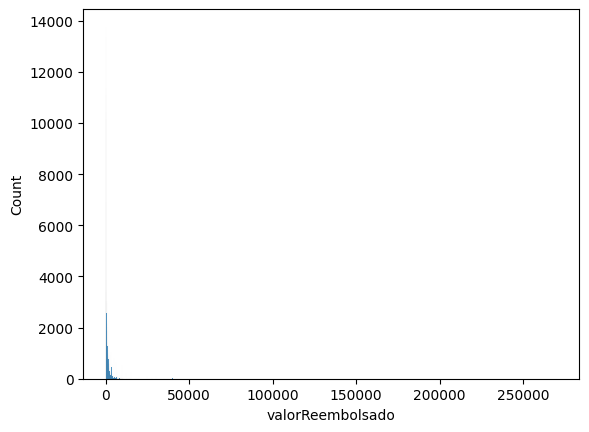

In [ ]:
sns.histplot(df["valorReembolsado"])

<Axes: xlabel='valorReembolsado', ylabel='Count'>

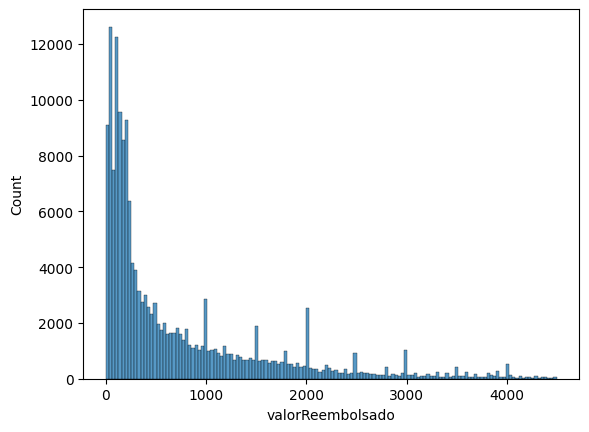

In [ ]:
# Como resolver essa visulização acima? vemos a existência de outliers estão "sujando" o histograma.

df_filter = df[df["valorReembolsado"] < df["valorReembolsado"].quantile(.95)]

sns.histplot(df_filter['valorReembolsado'])

In [ ]:
# Realize o .describe() desses dados filtrados.
df_filter[['valorReembolsado']].describe()

,valorReembolsado
count,165807.000000
mean,712.513486
std,870.051887
min,0.010000
25%,126.825000
50%,313.790000
75%,1000.000000
max,4496.030000


In [ ]:
# Vamos Entender os outliers? Possivelmente são informações importantes para simplemente serem descartadas.
# Realize o .describe() desses dados.

df_outliers = df[df["valorReembolsado"] >= df["valorReembolsado"].quantile(.95)]

df_outliers[['valorReembolsado']].describe()

,valorReembolsado
count,8909.000000
mean,9350.833820
std,8829.421373
min,4500.000000
25%,5362.670000
50%,6800.000000
75%,10000.000000
max,270000.000000


<Axes: ylabel='Count'>

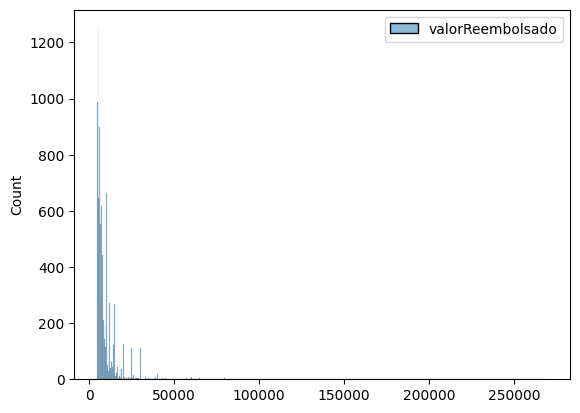

In [ ]:
sns.histplot(df_outliers[['valorReembolsado']])

Considerações da Analise Descritiva para próxima etapa de Análise sob a Tratamento de Valores Nulos e Valores Atípicos:

Ações Realizadas:
1. Verificar valores nulos presentes nas colunas documento e detalhamento
2. Verificar Comportamento da coluna valorReembolsado
3. Valores nulos presentes nas colunas documento e detalhamento não são pertinentes para eliminação ou de inserção de novos valores.

Ações Futuras:
1. Validar valores nulos da Col detalhamento
2. Tratativa para Valores Outliers

## Tratamento de Valores Nulos e Valores Atípicos

In [ ]:
10000 / df.valorReembolsado.sum()

4.964102043453286e-05

In [ ]:
df[df['detalhamento'].isna()]

,Unnamed: 0_x,id,tipoDocumento,ano,mes,nomeSenador,tipoDespesa,cpfCnpj,fornecedor,documento,...,Mandatos.Mandato.Titular.DescricaoParticipacao,Mandatos.Mandato.Titular.CodigoParlamentar,Mandatos.Mandato.Titular.NomeParlamentar,Mandatos.Mandato.Suplentes.Suplente.DescricaoParticipacao,Mandatos.Mandato.Suplentes.Suplente.CodigoParlamentar,Mandatos.Mandato.Suplentes.Suplente.NomeParlamentar,Mandatos.Mandato.Exercicios.Exercicio.CodigoExercicio,Mandatos.Mandato.Exercicios.Exercicio.DataInicio,Mandatos.Mandato.Exercicios.Exercicio.DataFim,Mandatos.Mandato.Exercicios.Exercicio.DescricaoCausaAfastamento
54,54,2000857,4,2015,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",5914650000166,ENERGISA,647777,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
290,290,2000792,3,2015,1,ALFREDO NASCIMENTO,"Aluguel de imóveis para escritório político, c...",2321157100,Gilberto Assunção de Oliveira,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
291,291,2000796,4,2015,1,ALFREDO NASCIMENTO,"Aluguel de imóveis para escritório político, c...",108786000165,Net,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
902,902,2025447,1,2015,12,ALVARO DIAS,"Locomoção, hospedagem, alimentação, combustíve...",7057670000193,Hotel Metrópole Maringá,29996,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1147,1147,2011576,1,2015,6,ALVARO DIAS,"Locomoção, hospedagem, alimentação, combustíve...",7686368000102,WTC - Sheraton,002270572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174708,173663,2191890,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",7845121000183,NASSER E FEITOZA COMÉRCIO DE COMBUSTIVEIS LTDA.,32380,...,NaN,NaN,NaN,NaN,NaN,NaN,2916.0,2019-02-01,NaT,NaN
174709,173664,2191863,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",7845121000183,NASSER E FEITOZA COMÉRCIO DE COMBUSTIVEIS LTDA.,33497,...,NaN,NaN,NaN,NaN,NaN,NaN,2916.0,2019-02-01,NaT,NaN
174710,173665,2191902,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",7845121000183,NASSER E FEITOZA COMÉRCIO DE COMBUSTIVEIS LTDA.,35299,...,NaN,NaN,NaN,NaN,NaN,NaN,2916.0,2019-02-01,NaT,NaN
174711,173666,2191292,2,2022,10,ZEQUINHA MARINHO,"Locomoção, hospedagem, alimentação, combustíve...",84146638000125,POSTO CAVALO DE AÇO LTDA.,133117,...,NaN,NaN,NaN,NaN,NaN,NaN,2916.0,2019-02-01,NaT,NaN


In [ ]:
# Calcule qual é a % de valores nulos na col detalhamento
len(df[df['detalhamento'].isna()]) / len(df) * 100

29.77918450513977

**é pertinente apagar ou alterar os valores nulos e outliers da base?**

Considerações da Analise Descritiva para próxima etapa de Análise sob a Tratamento de Valores Nulos e Valores Atípicos:

Ações Realizadas:
1. Validar valores nulos da Col detalhamento
2. Tratativa para Valores Outliers

Ações Futuras:
1. Extrair insights por visualização de dados


## Visualização de Dados

In [ ]:
# Filtro para Retirar Senadores que exerceram o mandato menos que 1 ano.
cod_senadores_menos_365dias = df_senadores[(~df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataFim'].isna()) &
                                           (df_senadores['Mandatos.Mandato.DescricaoParticipacao'] != 'Titular') &
                                           ((df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataFim'] - df_senadores['Mandatos.Mandato.Exercicios.Exercicio.DataInicio'] ).dt.days < 365)
                                          ]['IdentificacaoParlamentar.CodigoParlamentar'].values

In [ ]:
df_senadores_mais_365dias = df[~df['IdentificacaoParlamentar.CodigoParlamentar'].isin(cod_senadores_menos_365dias)]

In [ ]:
# Vamos ver quem são os 5 senadores mais gastões ou econômicos do senado? Utilize Tabelas para representar os metadados.

group_senador_valorReembolsado = df[['nomeSenador','IdentificacaoParlamentar.CodigoParlamentar','valorReembolsado']].groupby(['nomeSenador','IdentificacaoParlamentar.CodigoParlamentar']).sum(['valorReembolsado']).sort_values(by='valorReembolsado',ascending=False).reset_index()

group_senador_valorReembolsado = group_senador_valorReembolsado[~group_senador_valorReembolsado['IdentificacaoParlamentar.CodigoParlamentar'].isin(cod_senadores_menos_365dias)]

group_senador_valorReembolsado.head(5)

,nomeSenador,IdentificacaoParlamentar.CodigoParlamentar,valorReembolsado
0,PAULO ROCHA,374.0,3602758.48
1,TELMARIO MOTA,5535.0,3552478.33
2,DAVI ALCOLUMBRE,3830.0,3407374.58
3,OMAR AZIZ,5525.0,3367994.47
4,SERGIO PETECAO,4560.0,3324759.91


In [ ]:
group_senador_valorReembolsado.tail(5)

,nomeSenador,IdentificacaoParlamentar.CodigoParlamentar,valorReembolsado
192,LEILA BARROS,5979.0,10567.64
193,ANA RITA,4869.0,9189.45
194,PEDRO SIMON,68.0,8767.00
196,MARIO COUTO,4539.0,4016.60
198,EPITACIO CAFETEIRA,20.0,1865.95


Temos um problema, temos valores baixos pelo fato que normalmente senadores eleitos são substituidos temporariamente por N motivos por seus respectivos suplentes, nesse caso temos que classificar em **senadores titulares** e **senadores suplentes**.

Precisamos melhorar nossa base de dados, portanto, devemos procurar mais dados abertos sobre o mandato dos senadores. Para isso temos que voltar na etapa, fazer carregamento e enriquecimento de dados na primeira etapa.

Consulte as api neste [link](https://legis.senado.leg.br/dadosabertos/docs/resource_ListaSenadorService.html)

In [ ]:
# Qual são os 5 partidos Mais Gastões ou econômicos do senado?
# Utilize Tabelas para representar os metadados.

group_partido_valorReembolsado = df_senadores_mais_365dias

group_partido_valorReembolsado = df[['IdentificacaoParlamentar.SiglaPartidoParlamentar','valorReembolsado']].groupby(['IdentificacaoParlamentar.SiglaPartidoParlamentar']).sum(['valorReembolsado']).sort_values(by='valorReembolsado',ascending=False).reset_index()

group_partido_valorReembolsado.head(5)

,IdentificacaoParlamentar.SiglaPartidoParlamentar,valorReembolsado
0,MDB,36486238.98
1,PSD,25681474.25
2,PT,24348442.62
3,PP,19264409.34
4,PSDB,16940410.98


In [ ]:
group_partido_valorReembolsado.tail(5)

,IdentificacaoParlamentar.SiglaPartidoParlamentar,valorReembolsado
17,S/Partido,547091.39
18,CIDADANIA,229495.97
19,PRTB,153741.45
20,NOVO,140284.37
21,PV,123015.14


In [ ]:
# Faça um comparativo entre os mandatos de 2019 - 2022 e 2015 - 2018, qual foi o custo total para ambos mandatos por ano?
# Utilize Gráfico de linha para representar os metadados.




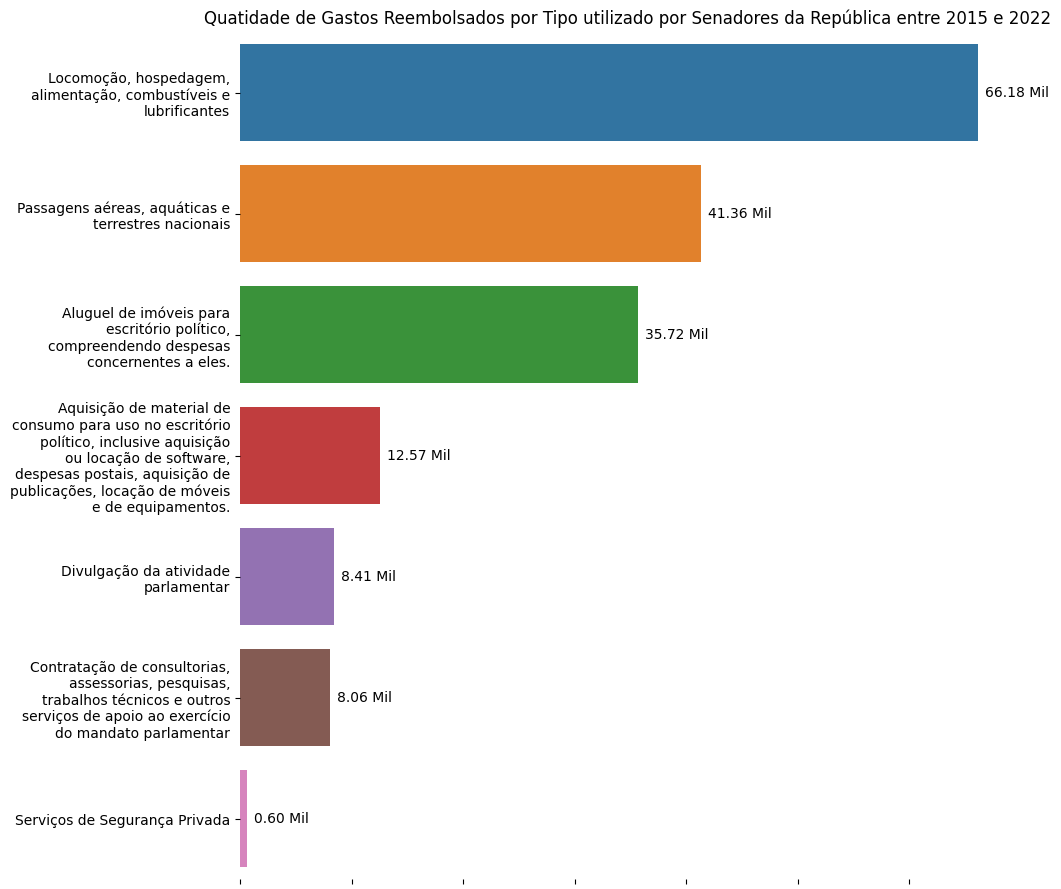

In [ ]:
# Qual são os 5 tipos de despesa mais utilizadas por senadores?
# Desfio: Some o restante dos tipos de despesas em uma barra "Outros"?
# Utilize Gráfico de Barra para representar os metadados.

group_despesa_quantidade = df_senadores_mais_365dias

group_despesa_quantidade = group_despesa_quantidade[['id','tipoDespesa']].groupby(['tipoDespesa']).count().sort_values(by='id',ascending=False).reset_index()

group_despesa_quantidade['id'] = group_despesa_quantidade.id * 0.001

group_despesa_quantidade['tipoDespesa'] = group_despesa_quantidade['tipoDespesa'].apply(lambda row: '\n'.join(wrap(row, 30)))

plt.figure(figsize=(10,11))
ax = sns.barplot(data=group_despesa_quantidade, x="id", y="tipoDespesa");
ax.set(xlabel=None, ylabel=None)
ax.set(xticklabels=[])
ax.bar_label(ax.containers[0], fmt='{:.2f} Mil', padding= 5)
ax.set(title='Quatidade de Gastos Reembolsados por Tipo utilizado por Senadores da República entre 2015 e 2022');
sns.despine(left=True, bottom=True)

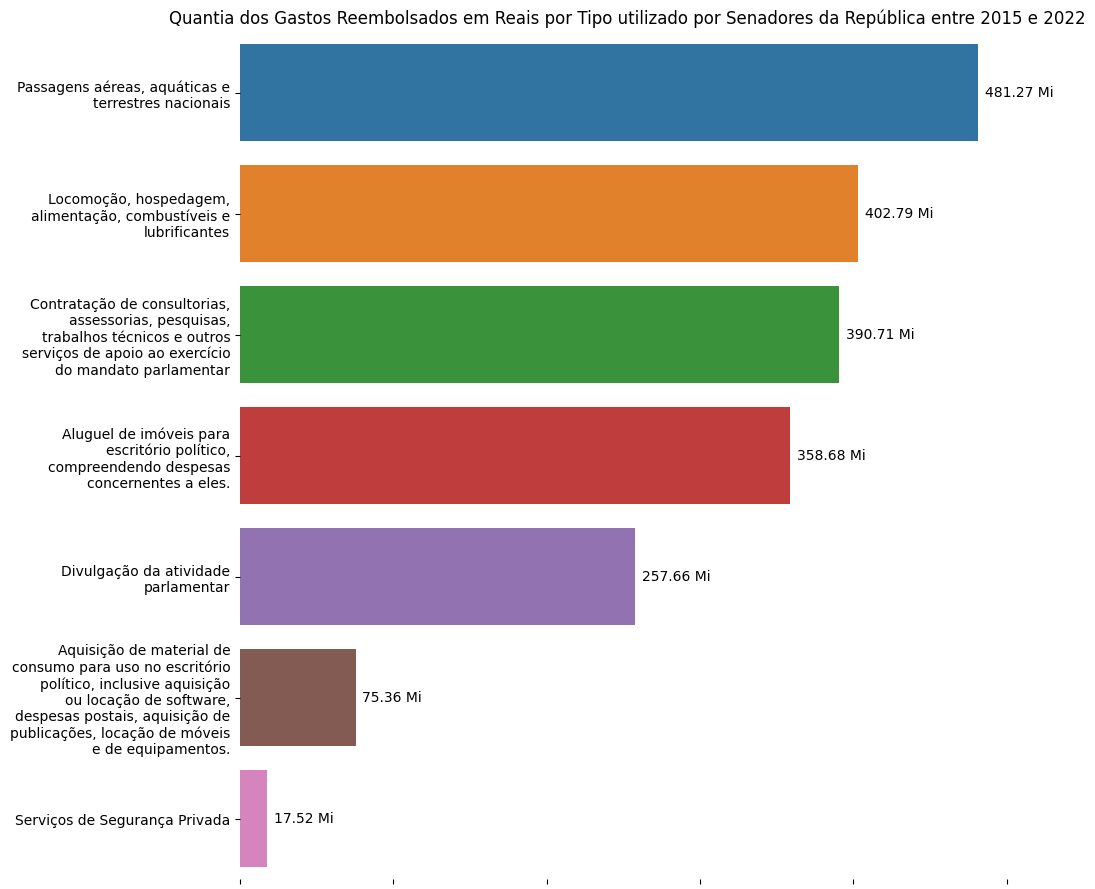

In [ ]:
# Qual são os 5 tipos de despesa mais gastas por senadores?
# Utilize Tabelas para representar os metadados.

group_despesa_valorReembolsado = df_senadores_mais_365dias

group_despesa_valorReembolsado = group_despesa_valorReembolsado[['tipoDespesa','valorReembolsado']].groupby(['tipoDespesa']).sum(['valorReembolsado']).sort_values(by='valorReembolsado',ascending=False).reset_index()

group_despesa_valorReembolsado['valorReembolsado'] = group_despesa_valorReembolsado.valorReembolsado * 0.00001

group_despesa_valorReembolsado['tipoDespesa'] = group_despesa_valorReembolsado['tipoDespesa'].apply(lambda row: '\n'.join(wrap(row, 30)))

plt.figure(figsize=(10,11))
ax = sns.barplot(data=group_despesa_valorReembolsado, x="valorReembolsado", y="tipoDespesa");
ax.set(xlabel=None, ylabel=None)
ax.set(xticklabels=[])
ax.bar_label(ax.containers[0], fmt='{:.2f} Mi', padding= 5)
ax.set(title='Quantia dos Gastos Reembolsados em Reais por Tipo utilizado por Senadores da República entre 2015 e 2022');
sns.despine(left=True, bottom=True)

In [ ]:
#group_gasto_valorReembolsado_medio.columns

NameError: ignored

In [ ]:
# Qual é o gasto médio entre Homens e Mulheres?
# Utilize Tabelas para representar os metadados.

group_gasto_valorReembolsado_medio = df_senadores_mais_365dias

group_gasto_valorReembolsado_medio[['IdentificacaoParlamentar.SexoParlamentar','valorReembolsado']].groupby(['IdentificacaoParlamentar.SexoParlamentar']).mean(['valorReembolsado']).sort_values(by='valorReembolsado',ascending=False).reset_index()

,IdentificacaoParlamentar.SexoParlamentar,valorReembolsado
0,Masculino,1168.117448
1,Feminino,1051.381742


In [ ]:
group_gasto_valorReembolsado_medio[['IdentificacaoParlamentar.SexoParlamentar','valorReembolsado']].groupby(['IdentificacaoParlamentar.SexoParlamentar']).median(['valorReembolsado']).sort_values(by='valorReembolsado',ascending=False).reset_index()

,IdentificacaoParlamentar.SexoParlamentar,valorReembolsado
0,Masculino,358.765
1,Feminino,356.050


In [ ]:
df_senador_sexo_legislatura = df[['IdentificacaoParlamentar.SexoParlamentar','numLegistlatura','IdentificacaoParlamentar.CodigoParlamentar']]

In [ ]:
df_senador_sexo_legislatura['IdentificacaoParlamentar.CodigoParlamentar'].astype(int)

IntCastingNaNError: ignored

In [ ]:
df_senador_sexo_legislatura['numLegistlatura']

In [ ]:
str(df_senador_sexo_legislatura['IdentificacaoParlamentar.CodigoParlamentar']) + '-' + df_senador_sexo_legislatura['numLegistlatura']

In [ ]:
df_senador_sexo_legislatura['CodigoParlamentar_numLegistlatura'] = str(df_senador_sexo_legislatura['IdentificacaoParlamentar.CodigoParlamentar']) + '-' + df_senador_sexo_legislatura['numLegistlatura']

In [ ]:
df_senador_sexo_legislatura['CodigoParlamentar_numLegistlatura']

In [ ]:
df_senador_sexo_legislatura['CodigoParlamentar_numLegistlatura'].unique()

In [ ]:
# Representividade Feminina aumentou em 2019 - 2022 em comparação a legislatura anteior?
# Utilize Gráfico de pizza para representar os metadados.

df_senador_sexo_legislatura = df[['IdentificacaoParlamentar.SexoParlamentar','numLegistlatura','IdentificacaoParlamentar.CodigoParlamentar']]



df_senadores[['IdentificacaoParlamentar.SexoParlamentar','numLegistlatura','IdentificacaoParlamentar.CodigoParlamentar']].groupby(['IdentificacaoParlamentar.SexoParlamentar','numLegistlatura']).count().reset_index()

"Se a saúde pública no Brasil parece estar ruim das pernas, isso jamais atingirá senadores, ex-senadores, suplentes que assumiram o cargo, tampouco seus cônjuges e dependentes. E para que isso seja possível, é exigido um único requisito destes políticos: exercício ininterrupto por 180 dias. Isso quer dizer que nenhum deles precisa contribuir para ter direito ao plano de saúde mais cobiçado do país."

[fonte](https://gilbert92.jusbrasil.com.br/artigos/141608410/plano-de-saude-de-senadores-e-vitalicio-completo-e-estendido-a-conjuge-e-dependentes)

com base na afirmação abaixo responda a alternativa abaixo:

In [ ]:
# Quais são os Senadores Suplentes exerceram mais de 180 dias de mandato?
# Utilize Tabelas para representar os metadados.

In [ ]:
# Existe uma Correlação entre idade do senador e gastos gerados por ele?
# Utilize Gráfico de disperssão para representar os metadados.

#### Dever de casa

Integre as bases [profissões](https://legis.senado.leg.br/dadosabertos/docs/resource_ListaSenadorService.html?_gl=1*1m0s91v*_ga*MjEyNTA3MDAxOC4xNjgwNDc3NzU2*_ga_CW3ZH25XMK*MTY4MTUyMTA1Ny40LjEuMTY4MTUyMTMzNi4wLjAuMA..#resource_ListaSenadorService_profissaoSenadorXml_GET) e [historicoAcademico](https://legis.senado.leg.br/dadosabertos/docs/resource_ListaSenadorService.html?_gl=1*1m0s91v*_ga*MjEyNTA3MDAxOC4xNjgwNDc3NzU2*_ga_CW3ZH25XMK*MTY4MTUyMTA1Ny40LjEuMTY4MTUyMTMzNi4wLjAuMA..#resource_ListaSenadorService_historicoAcademicoSenadorXml_GET) no EDA e gere visualizações e insights com esses novos dados.

#### Desafio

Correlacione o período da pandemia do COVID-19 com os gastos de CEAPS. Crie o merge dos dados e novas vizualizações sobre isso.